In [ ]:
import numpy as np
from sim_library.constants import pi, dR, hbar, k_eff, kb
from sim_library.plotting import plot_coolingcycles_22, fit_gaussian
from sim_library.simulation import simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate
import matplotlib.pyplot as plt

In [133]:
### Simulate many cycles of a pulse sequence with optical pumping after each one ###

# Set ensemble parameters
N = 50000
initial_temp = 5.9e-6

rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps, bs_corr=True, pi_corr=True)
RR3.build_seq()

# Cooling parameters
cycles = 64
pumping_route = 'f3' # optical pumping via either F'=2 ('f2') or F'=3 ('f3')

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[19] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

# Intensity noise
beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N) 
# beam_profile = np.full(N,1)

# Simulate cooling sequence
moms_list, fracs_list, _ = simulate_alg_cooling(basis=basis, sequence=RR3, n_atoms=N, temp=initial_temp, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route=pumping_route,
                                                        save_dir='data/algorithmic cooling/'
                                                        )

In [134]:
# Convert to units of hbark
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

# Finds highest/lowest momentum values across entire data
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

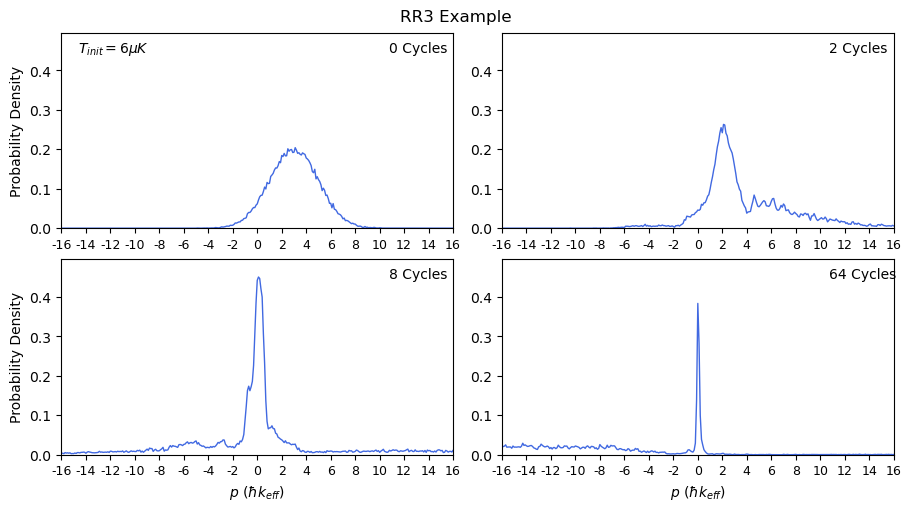

In [135]:
### Plot at different cycles ###

# For labelling
cycles_list = np.array([0,2,8,64])
index_list = np.array([0,4,16,128])
# For n cycles there will be 2n+1 'frames'
# Index of nth cycles will therefore be 2n

# Bin width (in units of hbar*k_eff)
bin_width = 0.1

# Plot 2x2 panels
plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bin_width=bin_width, title='RR3 Example', temp=initial_temp, show=False, datarange=global_range,
                     #   save_dir="plots/histograms/RR3_example.png"
                       )

Efficiency: 8.5367 +/- 0.0053106 %
Temperature: 0.0097454 +/- 0.0031254 muK
Center: 0.025772 +/- 0.0021995 hbark
Reduced chi-squared: 0.00061822


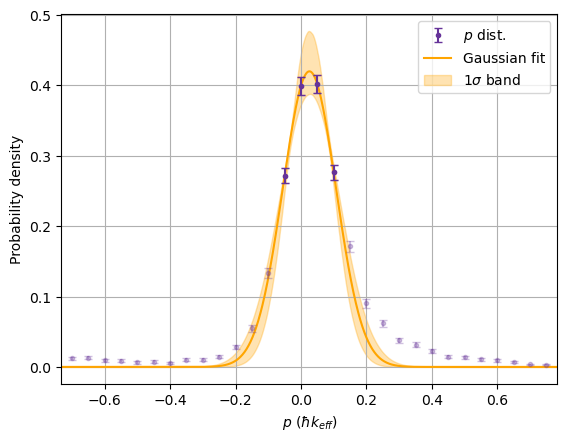

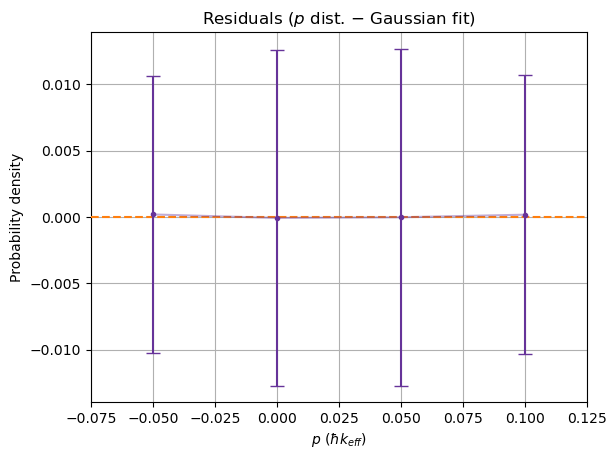

In [138]:
### Fitting gaussian with auto peak detection ###

# Width of domain relative to width of truncated data
# Default is 1
xscale = 10

# Fraction of peak height used to truncate data
# Default is 0.5 (i.e. FWHM)
threshold = 0.5

# Resolution (in units of hbar*k_eff)
bin_width = 0.05

amp, T, shift, errs, _, _ = fit_gaussian(moms_list[-1], fracs=fracs_list[-1], range = global_range, bin_width=bin_width, xscale=xscale, threshold=threshold,
                                   plot=True, 
                                   print_vals=True,
                                   joindata=False,
                                   plot_residuals=True
                                    )

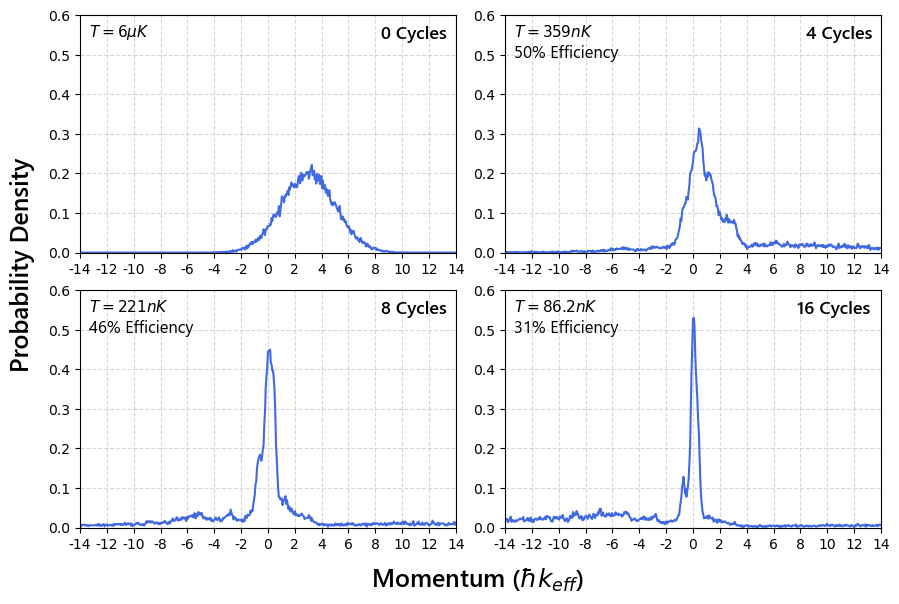

In [111]:
cycles_list = np.array([0,4,8,16])
index_list = np.array([0,8,16,32])
bins_list = np.full(4, 2000)
bins_list[0] = 2000

plt.rcParams['font.family'] = 'sans-serif'
fig, axes = plt.subplots(2,2, figsize=(8.5, 5.5), layout= 'constrained')
axes = axes.flatten()

top = 0.6

# global_min = min([min(m) for m in moms_list])
# global_max = max([max(m) for m in moms_list])
# global_range = (global_min, global_max)

for i in range(0,4):
        # counts, _, _ = axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i]], bins = bins_list[i], histtype='step', density=True, 
        #                             range=global_range,
        #                              linewidth = 1.5)
        counts, bin_edges = np.histogram(moms_list[index_list[i]], weights=fracs_list[index_list[i]], bins = bins_list[i], density=True, range=global_range)
        bindiff = bin_edges[1]-bin_edges[0]
        binmids = bin_edges[:-1] + (bindiff/2)
        axes[i].plot(binmids, counts, linewidth = 1.5, c = 'royalblue')
        axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 10)
        axes[i].set_xlim(-14,14)
        axes[i].grid(True, linestyle='--', alpha=0.5, zorder=0)

yticks = np.arange(int(top*20)+1)*0.05

for i in range(0,4):
    axes[i].set_ylim(0,top)
#     axes[i].set_yticks(yticks, [0.0, '', 0.1, '', 0.2, '', 0.3, ''], fontsize = 10)
    if i != 3:
        axes[i].text((len(basis)*0.74)+basis[0],top*0.9,rf'{cycles_list[i]} Cycles', fontname = 'Segoe UI', fontsize= 13, fontweight = 'semibold')

axes[3].text((len(basis)*0.72)+basis[0],top*0.9,rf'16 Cycles', fontname = 'Segoe UI', fontsize= 13, fontweight = 'semibold')

axes[0].text((len(basis)*0.08)+basis[0],top*0.91,rf'$T={5.9:.0f}\mu K$', fontname = 'Segoe UI',fontsize= 11, fontweight = 'semibold')
axes[1].text((len(basis)*0.08)+basis[0],top*0.91,rf'$T={359:.0f}nK$',fontname = 'Segoe UI', fontsize= 11, fontweight = 'semibold')
axes[2].text((len(basis)*0.08)+basis[0],top*0.91,rf'$T={221:.0f}nK$', fontname = 'Segoe UI', fontsize= 11, fontweight = 'semibold')
axes[3].text((len(basis)*0.08)+basis[0],top*0.91,rf'$T={86.2:.1f}nK$', fontname = 'Segoe UI', fontsize= 11, fontweight = 'semibold')

axes[1].text((len(basis)*0.08)+basis[0],top*0.82,rf'50% Efficiency',fontname = 'Segoe UI', fontsize= 12)
axes[2].text((len(basis)*0.08)+basis[0],top*0.82,rf'46% Efficiency',fontname = 'Segoe UI', fontsize= 12)
axes[3].text((len(basis)*0.08)+basis[0],top*0.82,rf'31% Efficiency',fontname = 'Segoe UI', fontsize= 12)

supy = fig.supylabel('Probability Density', fontname = 'Segoe UI', fontsize= 18, fontweight = 'semibold', x=-0.04, y=0.53)
supx = fig.supxlabel(r'Momentum ($\hbar k_{eff}$)', fontname= 'Segoe UI', fontsize= 18, fontweight = 'semibold', x=0.51, y=-0.07)


fig.savefig('plots/posters/histograms/RR3pulsorig_50katoms_500kHz_6muK_16cycles.svg', format='svg', bbox_inches='tight', bbox_extra_artists=(supx, supy))

In [113]:
### Simulate many cycles of a pulse sequence with optical pumping after each one ###

# Set ensemble parameters
N = 50000
# Initial flat momentum distribution
p_dist = np.random.uniform(-32,32, size=N)*hbar*k_eff

rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps, bs_corr=False, pi_corr=False)
RR3.build_seq()

# Cooling parameters
cycles = 8
pumping_route = 'f3' # optical pumping via either F'=2 ('f2') or F'=3 ('f3')

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[16] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

# Intensity noise
# beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N) 
beam_profile = np.full(N,1)

# Simulate cooling sequence
moms_list, fracs_list = simulate_alg_cooling_custom(basis=basis, sequence=RR3, p_dist=p_dist, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3',
                                                        save_dir='data/algorithmic cooling/flat',
                                                        )

In [114]:
# Convert to units of hbark
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

# Finds highest/lowest momentum values across entire data
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

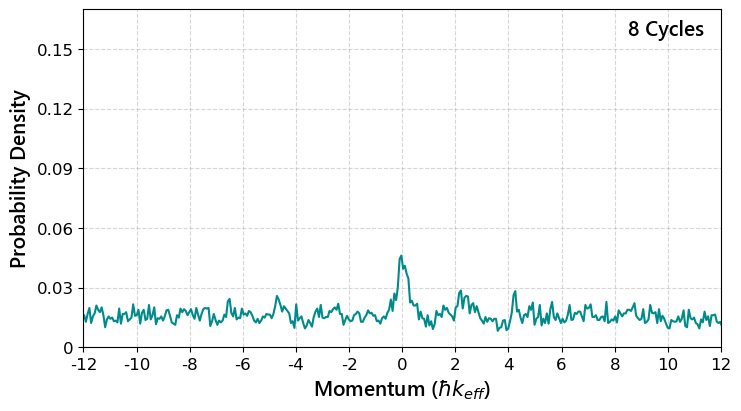

In [132]:
# plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(1,1, figsize=(7.3, 4), layout= 'constrained')

counts, bin_edges = np.histogram(moms_list[-1], weights=fracs_list[-1], bins = 2000, density=True, range=global_range)
bindiff = bin_edges[1]-bin_edges[0]
binmids = bin_edges[:-1] + (bindiff/2)
ax.plot(binmids, counts, linewidth=1.5, c = 'darkcyan')
ax.set_xticks(basis[0::2], basis[0::2], fontsize = 12)
ax.set_xlim(-12,12)

ax.set_ylim(0,0.17)
ax.set_yticks([0, 0.03, 0.06, 0.09, 0.12, 0.15], [0, 0.03, 0.06, 0.09, 0.12, 0.15], fontsize = 12)

ax.text(8.5,0.157,rf'{8} Cycles', fontname = 'Segoe UI', fontsize= 15, fontweight = 'semibold')
# ax.text(-11.5,0.157,rf'$T=$49.5 nK', fontname = 'Segoe UI', fontsize= 15)
# ax.text(-11.5,0.142,rf'19.6% Efficiency', fontname = 'Segoe UI', fontsize= 15)

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax.set_ylabel('Probability Density', fontname = 'Segoe UI', fontsize= 15, fontweight = 'semibold')
ax.set_xlabel(r'Momentum ($\hbar k_{eff}$)', fontname= 'Segoe UI', fontsize= 15, fontweight = 'semibold')

fig.savefig('plots/histograms/adjustedMDFE_500khz_flatbeamprof_confrev.pdf', format='pdf', bbox_inches='tight')